# Task 6.1 P
### Name: Nay Tun
### Student Id: 225110052

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import KNeighborsClassifier


## 1. Load "bank-additional-full.csv" dataset and create a logistic regression model for predicting target variable (subscribed a term deposit or not). Use appropriate evaluation methods and report the performance of the model using appropriate metrics.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/nay-deakin/sit720-data/refs/heads/main/bank-additional/bank-additional-full.csv", delimiter=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### See if there are null rows
##### Looks like there are none so we don't have to worry about nulls


In [4]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


### Lets look at text column to see if we need to do one hot encoding
### Also check which text column have how many unique values

In [5]:
for col in df.select_dtypes(include="object"):
    print (col, df[col].nunique(),list(df[col].unique()))

job 12 ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']
marital 4 ['married', 'single', 'divorced', 'unknown']
education 8 ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']
default 3 ['no', 'unknown', 'yes']
housing 3 ['no', 'yes', 'unknown']
loan 3 ['no', 'yes', 'unknown']
contact 2 ['telephone', 'cellular']
month 10 ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
day_of_week 5 ['mon', 'tue', 'wed', 'thu', 'fri']
poutcome 3 ['nonexistent', 'failure', 'success']
y 2 ['no', 'yes']


### Treat education as ordinal column
### Treat the rest of text columns as nominal and use One Hot Encoding
### The numeric columns as is

In [6]:
X = df.drop(columns='y')
y = df['y'].map({'yes':1, 'no': 0})

In [7]:
numeric_cols = list(X.select_dtypes(include=['float64', 'int64']).columns)
ordinal_cols = ['education']
education_order = [
    ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'unknown']
]
nominal_cols = [col for col in list(X.select_dtypes(include="object")) if col not in ordinal_cols]


##### Use sci-kit learn pipeline

In [8]:
nominal_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('nominal', nominal_pipeline, nominal_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols),
    ('numeric', StandardScaler(),   numeric_cols)   # numeric cols pass through unchanged
])

In [9]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=1, max_iter=5000)),
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [11]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10965
           1       0.68      0.43      0.53      1392

    accuracy                           0.91     12357
   macro avg       0.80      0.70      0.74     12357
weighted avg       0.90      0.91      0.90     12357

[[10680   285]
 [  794   598]]


ROC-AUC: 0.935


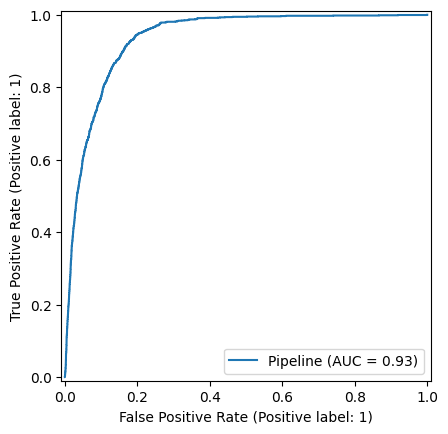

In [12]:
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC: {auc:.3f}")

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

### The data is inbalanced, there are more class 0 than class 1.
### In imbalanced problems, F1-score and ROC-AUC tell a much more honest story. The ROC-AUC of 0.935 shows the model is actually quite good at distinguishing subscribers from non-subscribers - it's just that the default 0.5 threshold makes it play it safe and lean toward predicting "no" most of the time. Lowering that threshold would let the model's true capability shine through.

- Class 1 precision 0.68, the model will predict correctly that someone will subscribe correctly 68% of the time.  It will get it wrong 32% of the time which means 32% of predictions are false alarms.
- Class 1 recall 0.43, the model only finds 43% of out of everyone who actually subscribed.  It is missing 57% of actual subscribers.
- Class 1 F1 = 0.53, the model is only slightly better than randomly guessing.

### From the confusing matrix 285 non-subsribers wrongly flagged as subscribers
### 794 real subcribers are missed


# 2. Have you used any hyperparameter tuning while building the model in Q1? If yes, then plot the performances that were obtained at different steps of optimisation. Otherwise, create an optimised model and compare performance with Q1.

### I did not do any hyperparameter tuning in Q1.
### code below will tune by using grid search cv


Best params: {'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear'}
Best CV F1:  0.589
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     10965
           1       0.44      0.87      0.59      1392

    accuracy                           0.86     12357
   macro avg       0.71      0.87      0.75     12357
weighted avg       0.92      0.86      0.88     12357

[[9446 1519]
 [ 177 1215]]
ROC-AUC: 0.935


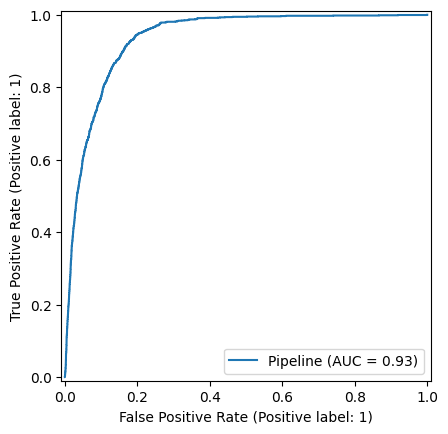

In [13]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100, 1000, 10000],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__solver': ['liblinear']
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1:  {grid_search.best_score_:.3f}")

y_pred_optimised = grid_search.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_optimised))
print(confusion_matrix(y_test, y_pred_optimised))

auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC: {auc:.3f}")

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

- Recall jumped from 0.43 to 0.87, the model now catches 87% of real subscribers instead of 43%
- Precision dropped from 0.68 to 0.44, it flags more false alarms because of the hyperparameter of class weight: balanced, it is now more aggressive looking for class 1
- Overall accuracy dropped from 0.91 to 0.86, because it is now predicting more class 1 including wrong ones.

### reading the confusion matrix, it is incorrectly pedicting 1519 non-subscribers as subsribers, compared to 285 before
### However now it only misses 177 real subscribers, as compared to 794 before.

# 3. Create two regularized logistic regression models for the predicting the target variable using the evaluation setting that you have used Q1 and report the performance.

In [14]:
# L1 model (use saga solver as it supports L1)
model_l1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l1',
        C=1,
        solver='saga',
        max_iter=5000,
        class_weight='balanced',
        random_state=1
    ))
])

# L2 model
model_l2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l2',
        C=1,
        solver='liblinear',
        max_iter=5000,
        class_weight='balanced',
        random_state=1
    ))
])

model_l1.fit(X_train, y_train)
model_l2.fit(X_train, y_train)

# Predict
y_pred_l1 = model_l1.predict(X_test)
y_pred_l2 = model_l2.predict(X_test)

# Reports
print("L1 Regularisation")
print(classification_report(y_test, y_pred_l1))
print(f"ROC-AUC: {roc_auc_score(y_test, model_l1.predict_proba(X_test)[:, 1]):.3f}")
print(confusion_matrix(y_test, y_pred_l1))
print ("\n")
print("L2 Regularisation")
print(classification_report(y_test, y_pred_l2))
print(confusion_matrix(y_test, y_pred_l2))
print(f"ROC-AUC: {roc_auc_score(y_test, model_l2.predict_proba(X_test)[:, 1]):.3f}")


L1 Regularisation
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     10965
           1       0.44      0.87      0.59      1392

    accuracy                           0.86     12357
   macro avg       0.71      0.87      0.75     12357
weighted avg       0.92      0.86      0.88     12357

ROC-AUC: 0.936
[[9444 1521]
 [ 176 1216]]


L2 Regularisation
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     10965
           1       0.44      0.87      0.59      1392

    accuracy                           0.86     12357
   macro avg       0.71      0.87      0.75     12357
weighted avg       0.92      0.86      0.88     12357

[[9443 1522]
 [ 177 1215]]
ROC-AUC: 0.936


### Both L1 and L2 models with C=1 produced identical results (ROC-AUC 0.936, Class 1 F1 0.59), suggesting that at this regularisation strength the penalty type has minimal impact on this dataset. L1 would show more differentiation at smaller values of C where it aggressively zeroes out coefficients.

# 4. Compare the performance of the three models (Q1 and Q3), explain which model is good and why.


## Model from Q1 is unoptimized (no hyperparam tuning)
## Models L1 and L2 have the same results

## Recall jumped from 0.43 to 0.87, the model now catches 87% of real subscribers instead of 43%
- Precision dropped from 0.68 to 0.44, it flags more false alarms because of the hyperparameter of class weight: balanced, it is now more aggressive looking for class 1
- Overall accuracy dropped from 0.91 to 0.86, because it is now predicting more class 1 including wrong ones.

### reading the confusion matrix, it is incorrectly pedicting 1519 non-subscribers as subsribers, compared to 285 before
### However now it only misses 177 real subscribers, as compared to 794 before.

# 5. Choose one of the above three models, change the prediction probability threshold to [0.2, 0.3, 0.4, 0.6, 0.7,0.8], report the model performance change and indicate which threshold is the best choice.

##### Lets choose model L1


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      0.74      0.85     10965
           1       0.32      0.98      0.48      1392

    accuracy                           0.76     12357
   macro avg       0.66      0.86      0.67     12357
weighted avg       0.92      0.76      0.81     12357

[[8089 2876]
 [  33 1359]]

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.80      0.88     10965
           1       0.37      0.95      0.53      1392

    accuracy                           0.81     12357
   macro avg       0.68      0.87      0.71     12357
weighted avg       0.92      0.81      0.84     12357

[[8720 2245]
 [  67 1325]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.83      0.90     10965
           1       0.41      0.92      0.57      1392

    accuracy                           0.84     12357
   macro avg       0.70   

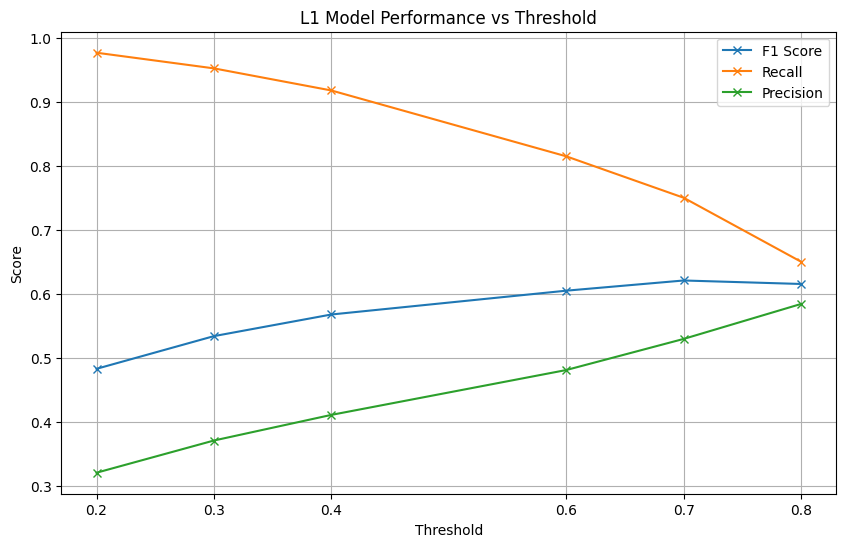

In [15]:
y_proba = model_l1.predict_proba(X_test)[:, 1]
thresholds = [0.2, 0.3, 0.4, 0.6, 0.7, 0.8]

f1_scores        = []
recall_scores    = []
precision_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)

    f1_scores.append(report['1']['f1-score'])
    recall_scores.append(report['1']['recall'])
    precision_scores.append(report['1']['precision'])

    print(f"\nThreshold: {thresh}")
    print(classification_report(y_test, y_pred_thresh))
    print(confusion_matrix(y_test, y_pred_thresh))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores,        marker='x', label='F1 Score')
plt.plot(thresholds, recall_scores,    marker='x', label='Recall')
plt.plot(thresholds, precision_scores, marker='x', label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('L1 Model Performance vs Threshold')
plt.legend()
plt.grid(True)
plt.xticks(thresholds)
plt.show()

### Threshold 0.7 is the best choice with the highest F1 score while retaining a higher recall.
### Threshold 0.8 has the similar F1 score but recall drop significantly.

# 6. Continue from question 4, with the same evaluation setting, use KNN and tune K on the training set, report the performance on the test set and the optimal K. Compare KNN with all the above logistic regression models, consider the following aspects: number of trainable parameters, training time and model performance. Explain why KNN is worse/better than logistic regression.

K=  3  CV F1: 0.491
K=  5  CV F1: 0.492
K=  7  CV F1: 0.491
K=  9  CV F1: 0.487
K= 11  CV F1: 0.482
K= 15  CV F1: 0.481
K= 21  CV F1: 0.465
K= 31  CV F1: 0.456

Best K: 5


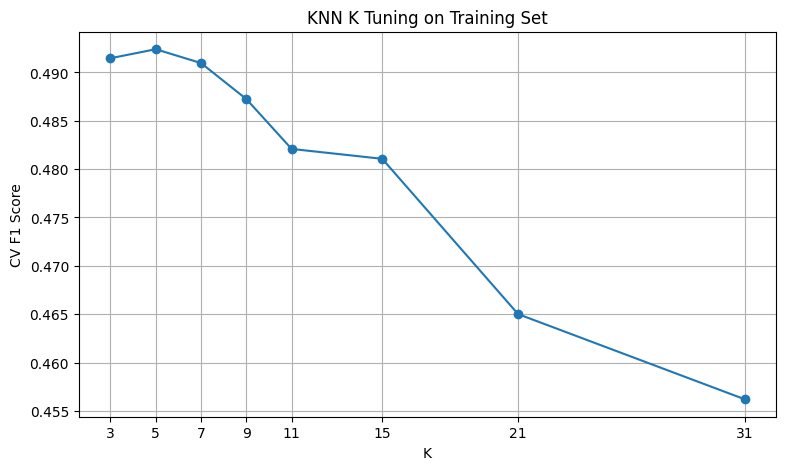

In [16]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

k_values = [3, 5, 7, 9, 11, 15, 21, 31]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_processed, y_train, cv=5, scoring='f1')
    cv_scores.append(scores.mean())
    print(f"K={k:3d}  CV F1: {scores.mean():.3f}")

best_k = k_values[np.argmax(cv_scores)]
print(f"\nBest K: {best_k}")

plt.figure(figsize=(9, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('K')
plt.ylabel('CV F1 Score')
plt.title('KNN K Tuning on Training Set')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [17]:
start = time.time()
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_processed, y_train)
knn_train_time = time.time() - start

# Predict and report
y_pred_knn = knn_final.predict(X_test_processed)
auc_knn = roc_auc_score(y_test, knn_final.predict_proba(X_test_processed)[:, 1])

print(f"KNN (K={best_k})")
print(classification_report(y_test, y_pred_knn))
print(f"ROC-AUC: {auc_knn:.3f}")

KNN (K=5)
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10965
           1       0.58      0.43      0.49      1392

    accuracy                           0.90     12357
   macro avg       0.75      0.69      0.72     12357
weighted avg       0.89      0.90      0.89     12357

ROC-AUC: 0.871


In [18]:
# Re-time each LR model for fair comparison

start = time.time()
model.fit(X_train, y_train)
time_l0 = time.time() - start

start = time.time()
model_l1.fit(X_train, y_train)
time_l1 = time.time() - start

start = time.time()
model_l2.fit(X_train, y_train)
time_l2 = time.time() - start


In [19]:
results = {
    'Model':       ['LR Baseline (Q1)', 'LR L1', 'LR L2', f'KNN (K={best_k})'],
    'Class1 F1':   [0.53, 0.59, 0.59, report['1']['f1-score']],
    'ROC-AUC':     [0.935, 0.936, 0.936, auc_knn],
    'Train Time':  [f'{time_l0:.2f}s', f'{time_l1:.2f}s', f'{time_l2:.2f}s', f'{knn_train_time:.2f}s'],
}

import pandas as pd
print(pd.DataFrame(results).to_string(index=False))
pd.DataFrame(results)

           Model  Class1 F1  ROC-AUC Train Time
LR Baseline (Q1)   0.530000 0.935000      2.90s
           LR L1   0.590000 0.936000      5.21s
           LR L2   0.590000 0.936000      0.49s
       KNN (K=5)   0.615437 0.870775      0.01s


,Model,Class1 F1,ROC-AUC,Train Time
0,LR Baseline (Q1),0.530000,0.935000,2.90s
1,LR L1,0.590000,0.936000,5.21s
2,LR L2,0.590000,0.936000,0.49s
3,KNN (K=5),0.615437,0.870775,0.01s


### Logistic Regression
- Training time: fast
- Prediction time: very fast
- Performance: Better on in-balance data with class_weight tuning
- Interpretability: High, coefficients show feature important

### KNN
- Training time: Near zero training
- Prediction time: Slow, computes distance to all training points for every prediction
- Performance: Struggles with imbalanced data and high dimensions
- Interpretability: None


#### The dataset has ~40k rows and many features after one hot encoding — KNN suffers in high dimensions (curse of dimensionality)
#### KNN has no built-in way to handle class imbalance like class_weight='balanced'
#### KNN treats all features equally — it can't down-weight irrelevant ones the way L1 regularisation can

# 7. Based on the above models and findings, explore which group of clients are more likely to subscribe a term deposit?

In [20]:
ohe_features     = preprocessor.named_transformers_['nominal']['ohe'].get_feature_names_out(nominal_cols).tolist()
ordinal_features = ordinal_cols
numeric_features = numeric_cols

all_features = ohe_features + ordinal_features + numeric_features


coefficients = model_l1.named_steps['classifier'].coef_[0]


In [21]:
coef_df = pd.DataFrame({
    'Feature':     all_features,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print("Top 10 features most likely to subscribe:")
print(coef_df.head(10))

print("\nTop 10 features least likely to subscribe:")
print(coef_df.tail(10))

Top 10 features most likely to subscribe:
                 Feature  Coefficient
25             month_mar     2.197461
38              duration     1.852461
43        cons.price.idx     1.533178
21             month_aug     1.202538
45             euribor3m     1.199699
35      poutcome_success     1.089395
4            job_retired     0.586119
29             month_sep     0.513718
34  poutcome_nonexistent     0.401883
46           nr.employed     0.392584

Top 10 features least likely to subscribe:
              Feature  Coefficient
5   job_self-employed    -0.219333
0     job_blue-collar    -0.223773
14    default_unknown    -0.318809
1    job_entrepreneur    -0.319979
13    marital_unknown    -0.468393
20  contact_telephone    -0.475126
27          month_nov    -0.623307
26          month_may    -0.827356
24          month_jun    -1.062969
42       emp.var.rate    -3.860230


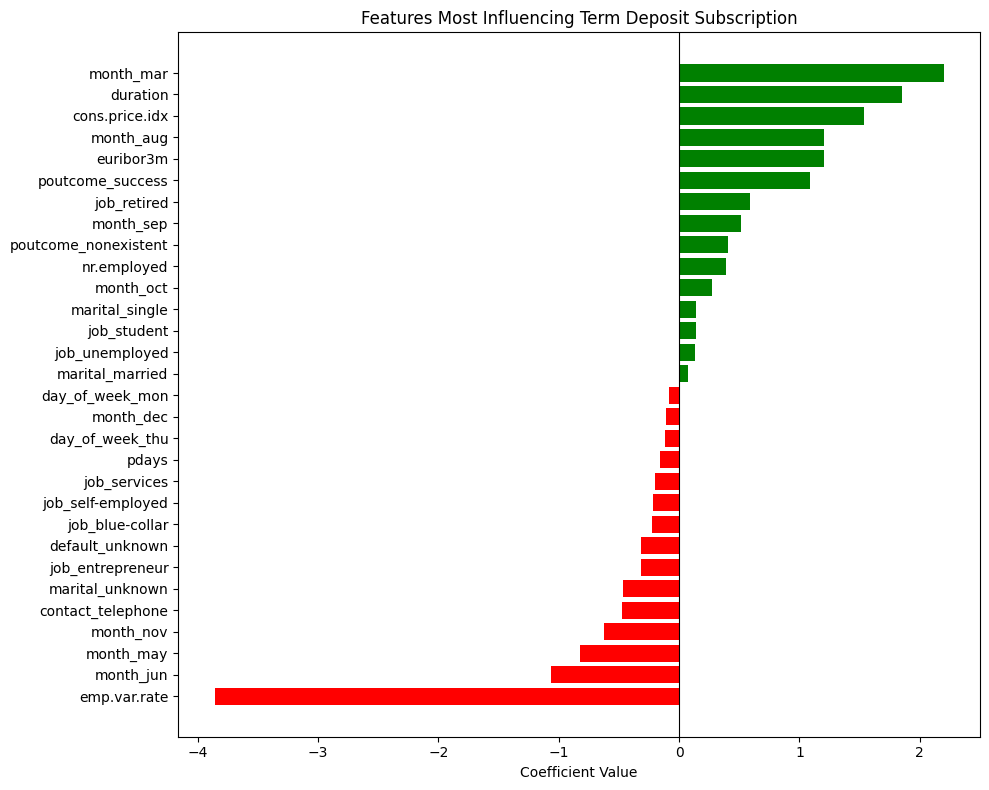

In [22]:

top_n = 15
top_pos = coef_df.head(top_n)
top_neg = coef_df.tail(top_n)
plot_df = pd.concat([top_pos, top_neg]).sort_values('Coefficient')

plt.figure(figsize=(10, 8))
colors = ['red' if c < 0 else 'green' for c in plot_df['Coefficient']]
plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Features Most Influencing Term Deposit Subscription')
plt.tight_layout()
plt.show()

In [23]:
profile = df.groupby('y')[nominal_cols + ordinal_cols + numeric_cols].mean(numeric_only=True)
print(profile)

for col in ['job', 'marital', 'education', 'contact', 'poutcome']:
    print(f"\n{col}")
    print(df.groupby(col)['y'].value_counts(normalize=True).unstack()['yes'].sort_values(ascending=False))

           age    duration  campaign       pdays  previous  emp.var.rate  \
y                                                                          
no   39.911185  220.844807  2.633085  984.113878  0.132374      0.248875   
yes  40.913147  553.191164  2.051724  792.035560  0.492672     -1.233448   

     cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
y                                                           
no        93.603757     -40.593097   3.811491  5176.166600  
yes       93.354386     -39.789784   2.123135  5095.115991  

job
job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.112121
technician       0.108260
self-employed    0.104856
housemaid        0.100000
entrepreneur     0.085165
services         0.081381
blue-collar      0.068943
Name: yes, dtype: float64

marital
marital
unknown     0.150000
single      0.140041
divorced    0.103209
married     0.101573
Nam

| Factor | More Likely to Subscribe |
|---|---|
| `poutcome` | Previous campaign was a **success** |
| `contact` | Contacted by **cellular** not telephone |
| `month` | Contacted in **March, December, October** |
| `job` | **Students** and **retired** clients |
| `education` | **University degree** holders |
| `marital` | **Single** clients |